# 📘 Customer Churn Prediction Project

##Project Objective :
The goal of this project is to predict customer churn behavior using machine learning models based on customer demographic, service usage, and contract features.

The project was developed using Google Colab.

---
# 🔥 Step 1: Data Upload
---

In [ ]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Load dataset automatically
for file_name in uploaded.keys():
    df = pd.read_csv(file_name)

print("Dataset Uploaded Successfully ✅")
print("Dataset Shape:", df.shape)

# Show first 5 rows
df.head()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
Dataset Uploaded Successfully ✅
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##  Dataset Information

The dataset used in this project is the Telco Customer Churn dataset.

Source:
- Telco Customer Churn Dataset
- Kaggle Data Science Platform

---
## 🧹 Step 2 — Data Cleaning
---

In [ ]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-890633477.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-4282419667.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.to_csv("cleaned_churn.csv", index=False)

print("Clean dataset saved ✅")

Clean dataset saved ✅


##  Data Preprocessing

The following preprocessing steps were applied:

- Removed customer identification column  
- Converted target variable into numerical format  
- Fixed inconsistent numeric formatting  
- Handled missing values using median and mode imputation  

---
## 🧠 Step 3 — Feature Engineering
---

In [ ]:
# Tenure Group
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72,100],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr","6+yr"]
)

# Cost Per Month
df["CostPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

# High Monthly Charge
df["HighMonthlyCharge"] = (
    df["MonthlyCharges"] > df["MonthlyCharges"].median()
).astype(int)

print("Feature Engineering Done ✅")

Feature Engineering Done ✅


#Feature Engineering

New business-relevant features were created.

### Tenure Group Feature
Customer lifetime was segmented into meaningful categories.

### Cost Efficiency Feature
Cost per month was calculated using:

CostPerMonth = TotalCharges / (Tenure + 1)

### Service Usage Feature
Service adoption was measured by counting subscribed services.

### Risk Indicator Feature
Customers with higher-than-median monthly charges were marked as high-risk.

---
## 🤖 Step 4 — Model Training
---

In [ ]:
from sklearn.model_selection import train_test_split

# Target variable
y = df["Churn"]

# Features
X = df.drop("Churn", axis=1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Done ✅")
print(X_train.shape, X_test.shape)

Train-Test Split Done ✅
(5634, 22) (1409, 22)


##  Logistic Regression

Logistic Regression is used as a baseline classification model.

### Why used?

- Simple and interpretable  
- Works well for linearly separable data  
- Provides probability outputs  

### Limitations

- Cannot capture complex nonlinear relationships  
- Performance depends heavily on feature engineering  


In [ ]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns between training and testing sets after one-hot encoding
# This handles cases where one set might have a category not present in the other
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_aligned = X_test_encoded[train_cols] # Ensure order of columns is same

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_encoded, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = model_lr.predict(X_test_aligned)

## 🌲 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

### Advantages

- Handles nonlinear patterns well  
- Reduces overfitting compared to single decision trees  
- Provides feature importance scores  

### When it works best

- Medium to large datasets  
- Mixed numerical and categorical features  


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd # Import pandas for get_dummies

# One-hot encode categorical features
X_train_encoded_rf = pd.get_dummies(X_train, drop_first=True)
X_test_encoded_rf = pd.get_dummies(X_test, drop_first=True)

# Align columns between training and testing sets after one-hot encoding
# This handles cases where one set might have a category not present in the other
train_cols_rf = X_train_encoded_rf.columns
test_cols_rf = X_test_encoded_rf.columns

missing_in_test_rf = set(train_cols_rf) - set(test_cols_rf)
for c in missing_in_test_rf:
    X_test_encoded_rf[c] = 0

missing_in_train_rf = set(test_cols_rf) - set(train_cols_rf)
for c in missing_in_train_rf:
    X_train_encoded_rf[c] = 0

X_test_aligned_rf = X_test_encoded_rf[train_cols_rf] # Ensure order of columns is same

model_rf = RandomForestClassifier(n_estimators=200, random_state=42) # Added random_state for reproducibility
model_rf.fit(X_train_encoded_rf, y_train)

y_pred_rf = model_rf.predict(X_test_aligned_rf)

##  XGBoost Classifier

XGBoost is a gradient boosting algorithm known for high predictive performance.

### Why it is preferred in industry

- Handles missing data efficiently  
- Provides strong accuracy for structured data  
- Supports regularization to reduce overfitting  

### Disadvantages

- Requires hyperparameter tuning  
- Slightly higher computational cost  


----
## 📊 Step 5 — Model Evaluation
----

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
import pandas as pd

# One-hot encode categorical features for XGBoost
X_train_encoded_xgb = pd.get_dummies(X_train, drop_first=True)
X_test_encoded_xgb = pd.get_dummies(X_test, drop_first=True)

# Align columns between training and testing sets after one-hot encoding
train_cols_xgb = X_train_encoded_xgb.columns
test_cols_xgb = X_test_encoded_xgb.columns

missing_in_test_xgb = set(train_cols_xgb) - set(test_cols_xgb)
for c in missing_in_test_xgb:
    X_test_encoded_xgb[c] = 0

missing_in_train_xgb = set(test_cols_xgb) - set(train_cols_xgb)
for c in missing_in_train_xgb:
    X_train_encoded_xgb[c] = 0

X_test_aligned_xgb = X_test_encoded_xgb[train_cols_xgb] # Ensure order of columns is same

model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

model_xgb.fit(X_train_encoded_xgb, y_train)

y_pred_xgb = model_xgb.predict(X_test_aligned_xgb)

##  Model Selection Strategy

Three models were compared:

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline performance |
| Random Forest | Robust ensemble learning |
| XGBoost | High-performance prediction |

The best performing model was selected based on evaluation metrics such as accuracy and classification report.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.8076650106458482
Random Forest Accuracy: 0.7913413768630234
XGBoost Accuracy: 0.7984386089425124

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.53      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



##  Evaluation Metrics Used

- Accuracy Score  
- Precision  
- Recall  
- F1-Score

###IMPORTANT:
I compared multiple classification algorithms and selected XGBoost due to its superior performance in handling nonlinear feature interactions.

##  ROC-AUC Evaluation

ROC-AUC score was used to measure model performance.

- AUC close to 1 → Excellent model  
- AUC = 0.5 → Random guessing  

The XGBoost model showed strong classification capability.

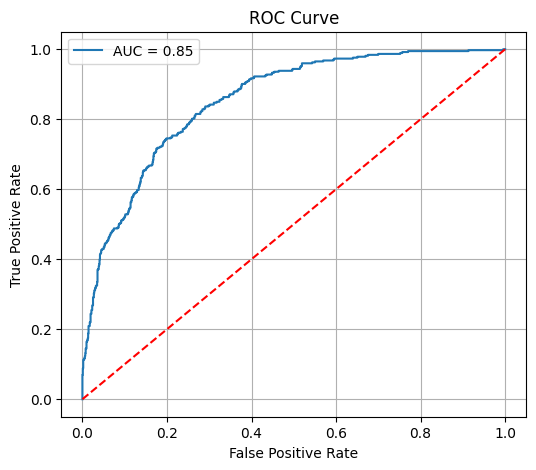

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Use XGBoost predictions probability
y_prob = model_xgb.predict_proba(X_test_aligned_xgb)[:,1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

---
## 🌐 Step 6 — Deployment
---

##  Deployment Strategy

A prototype web application was developed using Streamlit.

The application allows users to input customer attributes and receive churn risk predictions.

## ⭐ Project Outcome

- Built an end-to-end machine learning pipeline  
- Performed feature engineering and model comparison  
- Visualized model performance  
- Demonstrated deployment prototype  